# ADHD EEG Classification — LOSO EEGNet + NeuroGPT (Subject-level Evaluation)

This notebook uses the **same preprocessing logic** as the 80/20 notebook, but replaces the train/test split with **Leave-One-Subject-Out (LOSO)** evaluation.

Important change: because every held-out subject belongs to only one class, window-level F1 is misleading. This version evaluates LOSO at **subject level** by averaging all window ADHD scores for the held-out subject and making one final prediction per subject.


In [ ]:
import os
import sys
import random
import subprocess
from pathlib import Path
import pickle
import gc

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print("PyTorch:", torch.__version__)


Libraries imported successfully.
PyTorch: 2.10.0+cu128


In [ ]:

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

SEED = 42
set_seed(SEED)


Using device: cuda


## Dataset Path + Structure Check


In [53]:
print(os.listdir("/kaggle/input"))


['datasets']


In [54]:
BASE_PATH = "/kaggle/input/datasets/dannasalazar11/children-adhd-database"
ADHD_PATH = os.path.join(BASE_PATH, "ADHD_group")
CONTROL_PATH = os.path.join(BASE_PATH, "Control_group")

print("ADHD path exists:", os.path.exists(ADHD_PATH))
print("Control path exists:", os.path.exists(CONTROL_PATH))
print("ADHD files:", len(os.listdir(ADHD_PATH)))
print("Control files:", len(os.listdir(CONTROL_PATH)))


ADHD path exists: True
Control path exists: True
ADHD files: 61
Control files: 60


## Load ADHD + Control Subjects


In [ ]:
def load_subjects_from_folder(folder_path, label):
    X, y, subject_ids = [], [], []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".mat")])

    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            mat_data = sio.loadmat(file_path)
            available_keys = [k for k in mat_data.keys() if not k.startswith("__")]
            eeg_key = available_keys[0]
            eeg_signal = mat_data[eeg_key]

            if eeg_signal.shape[0] < eeg_signal.shape[1]:
                eeg_signal = eeg_signal.T

            X.append(eeg_signal.astype(np.float32))
            y.append(label)
            subject_ids.append(file.replace(".mat", ""))
        except Exception as e:
            print(f"Error loading {file}: {e}")

    return X, y, subject_ids


X_adhd, y_adhd, id_adhd = load_subjects_from_folder(ADHD_PATH, label=1)
X_control, y_control, id_control = load_subjects_from_folder(CONTROL_PATH, label=0)

X = X_adhd + X_control
y = np.array(y_adhd + y_control)
subject_ids = np.array(id_adhd + id_control)

subject_df = pd.DataFrame({"subject_id": subject_ids, "label": y})

print("Total subjects loaded:", len(X))
print("ADHD subjects:", len(X_adhd))
print("Control subjects:", len(X_control))
print("Subject-level labels:")
print(subject_df["label"].value_counts())


Total subjects loaded: 121
ADHD subjects: 61
Control subjects: 60
Subject-level labels:
label
1    61
0    60
Name: count, dtype: int64


In [56]:
shape_df = pd.DataFrame({
    "subject_id": subject_ids,
    "label": y,
    "shape": [signal.shape for signal in X]
})

display(shape_df.head(10))
print("Unique EEG shapes:")
print(shape_df["shape"].value_counts())

example_idx = 0
print("Example subject:", subject_ids[example_idx])
print("Label:", y[example_idx])
print("Shape:", X[example_idx].shape)
print("Min/Max/Mean:", np.min(X[example_idx]), np.max(X[example_idx]), np.mean(X[example_idx]))


,subject_id,label,shape
0,v10p,1,"(14304, 19)"
1,v12p,1,"(17604, 19)"
2,v14p,1,"(17562, 19)"
3,v15p,1,"(43252, 19)"
4,v173,1,"(24241, 19)"
5,v177,1,"(16697, 19)"
6,v179,1,"(12673, 19)"
7,v181,1,"(10668, 19)"
8,v183,1,"(18591, 19)"
9,v18p,1,"(25003, 19)"


Unique EEG shapes:
shape
(14304, 19)    1
(17604, 19)    1
(17562, 19)    1
(43252, 19)    1
(24241, 19)    1
              ..
(14139, 19)    1
(14692, 19)    1
(13918, 19)    1
(16513, 19)    1
(12929, 19)    1
Name: count, Length: 121, dtype: int64
Example subject: v10p
Label: 1
Shape: (14304, 19)
Min/Max/Mean: -2208.0 4802.0 149.6931


## Preprocessing — same as 80/20 notebook


In [57]:
FS = 128
LOWCUT = 1.0
HIGHCUT = 40.0
WINDOW_SECONDS = 4
WINDOW_SIZE = FS * WINDOW_SECONDS
OVERLAP = 0.5
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))

NUM_CHANNELS = 19
BATCH_SIZE = 32
THRESHOLD = 0.55

EEGNET_LOSO_EPOCHS = 5
NEUROGPT_LOSO_EPOCHS = 5

print("Sampling rate:", FS)
print("Window size:", WINDOW_SIZE)
print("Step size:", STEP_SIZE)
print("Threshold:", THRESHOLD)


Sampling rate: 128
Window size: 512
Step size: 256
Threshold: 0.55


In [58]:
def bandpass_filter(signal, fs=128, lowcut=1.0, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal, axis=0)


def zscore_normalize(signal):
    mean = np.mean(signal, axis=0, keepdims=True)
    std = np.std(signal, axis=0, keepdims=True)
    std[std == 0] = 1e-8
    return (signal - mean) / std


def segment_signal(signal, window_size=512, step_size=256):
    windows = []
    num_samples = signal.shape[0]
    for start in range(0, num_samples - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end, :])
    return np.array(windows, dtype=np.float32)


In [ ]:
X_windows_list = []
y_windows = []
subject_window_ids = []

for signal, label, subject_id in zip(X, y, subject_ids):
    filtered = bandpass_filter(signal, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT)
    normalized = zscore_normalize(filtered)
    windows = segment_signal(normalized, window_size=WINDOW_SIZE, step_size=STEP_SIZE)

    X_windows_list.append(windows)
    y_windows.extend([label] * len(windows))
    subject_window_ids.extend([subject_id] * len(windows))

X_windows = np.concatenate(X_windows_list, axis=0).astype(np.float32)
y_windows = np.array(y_windows).astype(np.float32)
subject_window_ids = np.array(subject_window_ids)

print("Preprocessing completed.")
print("X_windows shape:", X_windows.shape) 
print("y_windows shape:", y_windows.shape)
print("subject_window_ids shape:", subject_window_ids.shape)
print("Window-level class distribution:")
print(pd.Series(y_windows).value_counts())
print("Unique subjects:", len(np.unique(subject_window_ids)))


Preprocessing completed.
X_windows shape: (8279, 512, 19)
y_windows shape: (8279,)
subject_window_ids shape: (8279,)
Window-level class distribution:
1.0    4622
0.0    3657
Name: count, dtype: int64
Unique subjects: 121


## LOSO DataLoader Utilities


In [ ]:
def make_loso_data(test_subject, batch_size=BATCH_SIZE):
    """Leave one subject out. Train on all other subjects, test on the held-out subject."""
    train_mask = subject_window_ids != test_subject
    test_mask = subject_window_ids == test_subject

    X_train = X_windows[train_mask]
    y_train = y_windows[train_mask]
    subjects_train = subject_window_ids[train_mask]

    X_test = X_windows[test_mask]
    y_test = y_windows[test_mask]
    subjects_test = subject_window_ids[test_mask]

    assert len(set(subjects_train).intersection(set(subjects_test))) == 0, "Subject leakage detected!"
    assert len(np.unique(subjects_test)) == 1, "Test set should contain exactly one subject."

    X_train_eeg = np.transpose(X_train, (0, 2, 1))[:, np.newaxis, :, :]
    X_test_eeg = np.transpose(X_test, (0, 2, 1))[:, np.newaxis, :, :]

    X_train_tensor = torch.tensor(X_train_eeg, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_eeg, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    split_info = {
        "test_subject": test_subject,
        "train_subjects": len(np.unique(subjects_train)),
        "test_subjects": len(np.unique(subjects_test)),
        "train_windows": len(X_train_tensor),
        "test_windows": len(X_test_tensor),
        "train_adhd_windows": int(np.sum(y_train == 1)),
        "train_control_windows": int(np.sum(y_train == 0)),
        "test_adhd_windows": int(np.sum(y_test == 1)),
        "test_control_windows": int(np.sum(y_test == 0)),
    }

    return train_loader, test_loader, split_info


_tmp_subject = np.unique(subject_window_ids)[0]
_tmp_train_loader, _tmp_test_loader, _tmp_info = make_loso_data(_tmp_subject)
print(_tmp_info)
X_debug, y_debug = next(iter(_tmp_train_loader))
print("Batch shape:", X_debug.shape, y_debug.shape)


{'test_subject': np.str_('v107'), 'train_subjects': 120, 'test_subjects': 1, 'train_windows': 8203, 'test_windows': 76, 'train_adhd_windows': 4622, 'train_control_windows': 3581, 'test_adhd_windows': 0, 'test_control_windows': 76}
Batch shape: torch.Size([32, 1, 19, 512]) torch.Size([32])


## EEGNet Model


In [61]:
class EEGNet(nn.Module):
    def __init__(self, num_channels=19, num_samples=512, dropout_rate=0.5):
        super().__init__()

        self.firstconv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(8)
        )

        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=(num_channels, 1), groups=8, bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )

        self.separableConv = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, num_channels, num_samples)
            dummy_output = self.separableConv(self.depthwiseConv(self.firstconv(dummy_input)))
            flatten_size = dummy_output.reshape(1, -1).shape[1]

        self.classifier = nn.Linear(flatten_size, 1)

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x.squeeze(1)


print(EEGNet(num_channels=NUM_CHANNELS, num_samples=WINDOW_SIZE))


EEGNet(
  (firstconv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (depthwiseConv): Sequential(
    (0): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (separableConv): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)


## Training / Evaluation Functions for LOSO


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_loso_subject_level(model, loader, device, threshold=THRESHOLD):
    """
    LOSO subject-level evaluation.

    The held-out subject has only one true label, but many EEG windows.
    We average all window probabilities into one subject_score and then make
    one subject-level prediction.
    """
    model.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            scores = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            all_scores.extend(scores)
            all_labels.extend(y_batch.numpy().reshape(-1))

    all_scores = np.array(all_scores, dtype=float)
    all_labels = np.array(all_labels).astype(int)

    unique_labels = np.unique(all_labels)
    if len(unique_labels) != 1:
        print("WARNING: held-out subject contains more than one label:", unique_labels)

    subject_true = int(np.round(all_labels.mean()))
    subject_score = float(all_scores.mean())
    subject_pred = int(subject_score >= threshold)
    correct = int(subject_true == subject_pred)

    result = {
        "subject_true": subject_true,
        "subject_pred": subject_pred,
        "subject_score": subject_score,
        "correct": correct,
        "accuracy": correct,  
        "window_score_mean": float(all_scores.mean()),
        "window_score_std": float(all_scores.std()),
        "window_score_min": float(all_scores.min()),
        "window_score_max": float(all_scores.max()),
        "n_windows": int(len(all_scores)),
    }

    scores_df = pd.DataFrame({
        "true_label": all_labels,
        "adhd_score": all_scores,
    })
    scores_df["subject_true"] = subject_true
    scores_df["subject_pred"] = subject_pred
    scores_df["subject_score"] = subject_score
    scores_df["correct"] = correct

    return result, scores_df


def summarize_subject_level(results_df):
    """Compute final LOSO metrics across held-out subjects."""
    rows = []

    for model_name, df in results_df.groupby("model"):
        y_true_subject = df["subject_true"].astype(int)
        y_pred_subject = df["subject_pred"].astype(int)

        rows.append({
            "model": model_name,
            "accuracy": accuracy_score(y_true_subject, y_pred_subject),
            "precision": precision_score(y_true_subject, y_pred_subject, zero_division=0),
            "recall": recall_score(y_true_subject, y_pred_subject, zero_division=0),
            "f1": f1_score(y_true_subject, y_pred_subject, zero_division=0),
            "n_subjects": len(df),
            "n_correct_subjects": int((y_true_subject.values == y_pred_subject.values).sum()),
        })

    return pd.DataFrame(rows)


def train_model_loso(
    model_class,
    model_name,
    test_subject,
    epochs=5,
    lr=0.001,
    threshold=THRESHOLD,
    model_kwargs=None,
    fix_function=None
):
    set_seed(SEED)
    train_loader, test_loader, split_info = make_loso_data(test_subject, batch_size=BATCH_SIZE)

    if model_kwargs is None:
        model_kwargs = {}

    model = model_class(**model_kwargs).to(DEVICE)

    if fix_function is not None:
        model = fix_function(model)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_correct = -1
    best_distance_from_threshold = -1.0
    best_results = None
    best_scores_df = None
    safe_subject = str(test_subject).replace("/", "_").replace(" ", "_")
    best_model_path = f"best_{model_name}_loso_subject_{safe_subject}.pth"

    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        result, scores_df = evaluate_loso_subject_level(model, test_loader, DEVICE, threshold)

        distance_from_threshold = abs(result["subject_score"] - threshold)

        history.append({
            "model": model_name,
            "test_subject": test_subject,
            "epoch": epoch,
            "train_loss": train_loss,
            **result,
        })

        if (result["correct"] > best_correct) or (
            result["correct"] == best_correct and distance_from_threshold > best_distance_from_threshold
        ):
            best_correct = result["correct"]
            best_distance_from_threshold = distance_from_threshold
            torch.save(model.state_dict(), best_model_path)

            best_results = {
                "model": model_name,
                "test_subject": test_subject,
                "best_epoch": epoch,
                **result,
                "best_model_path": best_model_path,
                **split_info,
            }

            best_scores_df = scores_df.copy()
            best_scores_df["model"] = model_name
            best_scores_df["test_subject"] = test_subject
            best_scores_df["best_epoch"] = epoch

        print(
            f"{model_name} | subject {test_subject} | epoch {epoch:03d}/{epochs} | "
            f"loss {train_loss:.4f} | true {result['subject_true']} | "
            f"pred {result['subject_pred']} | score {result['subject_score']:.4f} | "
            f"correct {result['correct']}"
        )

    history_df = pd.DataFrame(history)
    history_df.to_csv(f"{model_name}_loso_history_subject_{safe_subject}.csv", index=False)
    best_scores_df.to_csv(f"{model_name}_loso_scores_subject_{safe_subject}.csv", index=False)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_results, history_df, best_scores_df


## Train EEGNet with LOSO


In [63]:
subjects = np.unique(subject_window_ids)
print("Number of LOSO subjects:", len(subjects))
print(subjects)


Number of LOSO subjects: 121
['v107' 'v108' 'v109' 'v10p' 'v110' 'v111' 'v112' 'v113' 'v114' 'v115'
 'v116' 'v117' 'v118' 'v120' 'v121' 'v123' 'v125' 'v127' 'v129' 'v12p'
 'v131' 'v133' 'v134' 'v138' 'v140' 'v143' 'v147' 'v149' 'v14p' 'v151'
 'v15p' 'v173' 'v177' 'v179' 'v181' 'v183' 'v18p' 'v190' 'v196' 'v198'
 'v19p' 'v1p' 'v200' 'v204' 'v206' 'v209' 'v20p' 'v213' 'v215' 'v219'
 'v21p' 'v227' 'v22p' 'v231' 'v234' 'v236' 'v238' 'v244' 'v246' 'v24p'
 'v250' 'v254' 'v25p' 'v263' 'v265' 'v270' 'v274' 'v279' 'v27p' 'v284'
 'v286' 'v288' 'v28p' 'v297' 'v298' 'v299' 'v29p' 'v300' 'v302' 'v303'
 'v304' 'v305' 'v306' 'v307' 'v308' 'v309' 'v30p' 'v310' 'v31p' 'v32p'
 'v33p' 'v34p' 'v35p' 'v36p' 'v37p' 'v38p' 'v39p' 'v3p' 'v40p' 'v41p'
 'v42p' 'v43p' 'v44p' 'v45p' 'v46p' 'v47p' 'v48p' 'v49p' 'v50p' 'v51p'
 'v52p' 'v53p' 'v54p' 'v55p' 'v56p' 'v57p' 'v58p' 'v59p' 'v60p' 'v6p'
 'v8p']


In [65]:
eegnet_loso_results = []
eegnet_loso_histories = {}
eegnet_loso_scores = {}

for test_subject in subjects:
    print("" + "=" * 90)
    print("EEGNet LOSO test subject:", test_subject)
    print("=" * 90)

    result, hist, scores_df = train_model_loso(
        model_class=EEGNet,
        model_name="eegnet",
        test_subject=test_subject,
        epochs=EEGNET_LOSO_EPOCHS,
        lr=0.001,
        threshold=THRESHOLD,
        model_kwargs={
            "num_channels": NUM_CHANNELS,
            "num_samples": WINDOW_SIZE,
            "dropout_rate": 0.5
        },
        fix_function=None
    )

    eegnet_loso_results.append(result)
    eegnet_loso_histories[test_subject] = hist
    eegnet_loso_scores[test_subject] = scores_df

    pd.DataFrame(eegnet_loso_results).to_csv("eegnet_loso_results_partial.csv", index=False)
    with open("eegnet_loso_histories_partial.pkl", "wb") as f:
        pickle.dump(eegnet_loso_histories, f)
    with open("eegnet_loso_scores_partial.pkl", "wb") as f:
        pickle.dump(eegnet_loso_scores, f)

eegnet_loso_results_df = pd.DataFrame(eegnet_loso_results)
eegnet_loso_results_df.to_csv("eegnet_loso_results.csv", index=False)
display(eegnet_loso_results_df)


EEGNet LOSO test subject: v107
eegnet | subject v107 | epoch 001/5 | loss 0.6374 | true 0 | pred 0 | score 0.1666 | correct 1
eegnet | subject v107 | epoch 002/5 | loss 0.4780 | true 0 | pred 0 | score 0.0613 | correct 1
eegnet | subject v107 | epoch 003/5 | loss 0.3913 | true 0 | pred 0 | score 0.0301 | correct 1
eegnet | subject v107 | epoch 004/5 | loss 0.3408 | true 0 | pred 0 | score 0.0191 | correct 1
eegnet | subject v107 | epoch 005/5 | loss 0.3157 | true 0 | pred 0 | score 0.0166 | correct 1
EEGNet LOSO test subject: v108
eegnet | subject v108 | epoch 001/5 | loss 0.6351 | true 0 | pred 0 | score 0.2389 | correct 1
eegnet | subject v108 | epoch 002/5 | loss 0.4818 | true 0 | pred 0 | score 0.0406 | correct 1
eegnet | subject v108 | epoch 003/5 | loss 0.3918 | true 0 | pred 0 | score 0.0104 | correct 1
eegnet | subject v108 | epoch 004/5 | loss 0.3478 | true 0 | pred 0 | score 0.0064 | correct 1
eegnet | subject v108 | epoch 005/5 | loss 0.3136 | true 0 | pred 0 | score 0.0040 

,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,n_windows,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,eegnet,v107,5,0,0,0.016644,1,1,0.016644,0.014867,...,76,best_eegnet_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76
1,eegnet,v108,5,0,0,0.003984,1,1,0.003984,0.006892,...,73,best_eegnet_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73
2,eegnet,v109,4,0,0,0.055831,1,1,0.055831,0.034192,...,61,best_eegnet_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61
3,eegnet,v10p,5,1,1,0.918015,1,1,0.918015,0.058766,...,54,best_eegnet_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0
4,eegnet,v110,4,0,0,0.025974,1,1,0.025974,0.016817,...,63,best_eegnet_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,eegnet,v58p,1,0,1,0.969258,0,0,0.969258,0.019785,...,53,best_eegnet_loso_subject_v58p.pth,120,1,8226,53,4622,3604,0,53
117,eegnet,v59p,5,0,1,0.870111,0,0,0.870111,0.100487,...,63,best_eegnet_loso_subject_v59p.pth,120,1,8216,63,4622,3594,0,63
118,eegnet,v60p,2,0,0,0.247881,1,1,0.247881,0.097117,...,49,best_eegnet_loso_subject_v60p.pth,120,1,8230,49,4622,3608,0,49
119,eegnet,v6p,5,1,1,0.881371,1,1,0.881371,0.110387,...,67,best_eegnet_loso_subject_v6p.pth,120,1,8212,67,4555,3657,67,0


In [90]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

THRESHOLD = 0.55 

def categorize_adhd_score(score):
    if score < 0.40:
        return "No ADHD indication"
    elif score <= THRESHOLD:
        return "Potential ADHD indication"
    else:
        return "Strong ADHD indication"


loso_results_df = pd.concat(
    [
        eegnet_loso_results_df.copy(),
        neurogpt_loso_results_df.copy()
    ],
    ignore_index=True
)

loso_results_df["subject_pred"] = (
    loso_results_df["subject_score"] >= THRESHOLD
).astype(int)

loso_results_df["correct"] = (
    loso_results_df["subject_true"].astype(int) ==
    loso_results_df["subject_pred"].astype(int)
).astype(int)

loso_results_df["score_category"] = loso_results_df["subject_score"].apply(
    categorize_adhd_score
)

summary_rows = []

for model_name, df in loso_results_df.groupby("model"):
    y_true = df["subject_true"].astype(int)
    y_pred = df["subject_pred"].astype(int)

    summary_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_subjects": len(df),
        "correct_subjects": int((y_true == y_pred).sum())
    })

loso_subject_summary_df = pd.DataFrame(summary_rows)

loso_results_df.to_csv(
    "loso_subject_level_results_eegnet_neurogpt_consistent_threshold.csv",
    index=False
)

loso_subject_summary_df.to_csv(
    "loso_subject_level_summary_eegnet_neurogpt_consistent_threshold.csv",
    index=False
)

display(loso_results_df.head())
display(loso_subject_summary_df)
display(loso_results_df["score_category"].value_counts())

,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows,score_category
0,eegnet,v107,5,0,0,0.016644,1,1,0.016644,0.014867,...,best_eegnet_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76,No ADHD indication
1,eegnet,v108,5,0,0,0.003984,1,1,0.003984,0.006892,...,best_eegnet_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73,No ADHD indication
2,eegnet,v109,4,0,0,0.055831,1,1,0.055831,0.034192,...,best_eegnet_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61,No ADHD indication
3,eegnet,v10p,5,1,1,0.918015,1,1,0.918015,0.058766,...,best_eegnet_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0,Strong ADHD indication
4,eegnet,v110,4,0,0,0.025974,1,1,0.025974,0.016817,...,best_eegnet_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63,No ADHD indication


,model,accuracy,precision,recall,f1,n_subjects,correct_subjects
0,eegnet,0.818182,0.782609,0.885246,0.830769,121,99
1,neurogpt,0.884298,0.821918,0.983607,0.895522,121,107


score_category
Strong ADHD indication       142
No ADHD indication            91
Potential ADHD indication      9
Name: count, dtype: int64

In [66]:
eegnet_loso_summary = summarize_subject_level(eegnet_loso_results_df)
eegnet_loso_summary.to_csv("eegnet_loso_subject_level_summary.csv", index=False)

display(eegnet_loso_results_df)
display(eegnet_loso_summary)


,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,n_windows,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,eegnet,v107,5,0,0,0.016644,1,1,0.016644,0.014867,...,76,best_eegnet_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76
1,eegnet,v108,5,0,0,0.003984,1,1,0.003984,0.006892,...,73,best_eegnet_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73
2,eegnet,v109,4,0,0,0.055831,1,1,0.055831,0.034192,...,61,best_eegnet_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61
3,eegnet,v10p,5,1,1,0.918015,1,1,0.918015,0.058766,...,54,best_eegnet_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0
4,eegnet,v110,4,0,0,0.025974,1,1,0.025974,0.016817,...,63,best_eegnet_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,eegnet,v58p,1,0,1,0.969258,0,0,0.969258,0.019785,...,53,best_eegnet_loso_subject_v58p.pth,120,1,8226,53,4622,3604,0,53
117,eegnet,v59p,5,0,1,0.870111,0,0,0.870111,0.100487,...,63,best_eegnet_loso_subject_v59p.pth,120,1,8216,63,4622,3594,0,63
118,eegnet,v60p,2,0,0,0.247881,1,1,0.247881,0.097117,...,49,best_eegnet_loso_subject_v60p.pth,120,1,8230,49,4622,3608,0,49
119,eegnet,v6p,5,1,1,0.881371,1,1,0.881371,0.110387,...,67,best_eegnet_loso_subject_v6p.pth,120,1,8212,67,4555,3657,67,0


,model,accuracy,precision,recall,f1,n_subjects,n_correct_subjects
0,eegnet,0.818182,0.782609,0.885246,0.830769,121,99


## NeuroGPT Setup


In [67]:
if not os.path.exists("/kaggle/working/NeuroGPT"):
    subprocess.run(["git", "clone", "https://github.com/wenhui0206/NeuroGPT.git", "/kaggle/working/NeuroGPT"], check=True)
else:
    print("NeuroGPT already exists.")

NEUROGPT_SRC_PATH = "/kaggle/working/NeuroGPT/src"
if NEUROGPT_SRC_PATH not in sys.path:
    sys.path.append(NEUROGPT_SRC_PATH)

from encoder.conformer_braindecode import EEGConformer
print("EEGConformer imported successfully.")


Cloning into '/kaggle/working/NeuroGPT'...


EEGConformer imported successfully.


In [ ]:
class NeuroGPT_ADHD(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EEGConformer(
            n_outputs=1,
            n_chans=NUM_CHANNELS,
            n_times=WINDOW_SIZE,
            is_decoding_mode=True
        )

    def forward(self, x):
        if x.dim() == 4:
            x = x.squeeze(1)      
        x = x.unsqueeze(1)         
        out = self.encoder(x)
        return out.reshape(-1)


class NeuroGPTFixedFC(nn.Module):
    def __init__(self, input_dim, out_channels=256, hidden_channels=32, dropout=0.5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, out_channels),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(out_channels, hidden_channels),
            nn.ELU()
        )

    def forward(self, x):
        x = x.contiguous().reshape(x.size(0), -1)
        return self.fc(x)


def detect_neurogpt_feature_dim(model):
    model.eval()
    with torch.no_grad():
        x_debug = torch.zeros(2, 1, NUM_CHANNELS, WINDOW_SIZE).to(DEVICE)
        x_debug = x_debug.squeeze(1).unsqueeze(1)

        batch, chunks, chann, time = x_debug.size()
        x_tmp = x_debug.contiguous().view(batch * chunks, chann, time)
        x_tmp = torch.unsqueeze(x_tmp, dim=1)
        x_tmp = model.encoder.patch_embedding(x_tmp)
        x_tmp = model.encoder.transformer(x_tmp)
        input_dim = x_tmp.contiguous().view(x_tmp.size(0), -1).shape[1]
    return input_dim


def fix_neurogpt_model(model):
    input_dim = detect_neurogpt_feature_dim(model)
    print("Detected NeuroGPT feature dimension:", input_dim)

    model.encoder.fc = NeuroGPTFixedFC(
        input_dim=input_dim,
        out_channels=256,
        hidden_channels=32,
        dropout=0.5
    ).to(DEVICE)

    model.encoder.final_layer.final_layer = nn.Sequential(
        nn.Linear(32, 1)
    ).to(DEVICE)

    return model


_tmp_model = fix_neurogpt_model(NeuroGPT_ADHD().to(DEVICE))
_tmp_x, _tmp_y = next(iter(_tmp_train_loader))
with torch.no_grad():
    _tmp_out = _tmp_model(_tmp_x[:4].to(DEVICE))
print("NeuroGPT test output shape:", _tmp_out.shape)

del _tmp_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120
NeuroGPT test output shape: torch.Size([4])


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


## Train NeuroGPT with LOSO


In [70]:
neurogpt_loso_results = []
neurogpt_loso_histories = {}
neurogpt_loso_scores = {}

for test_subject in subjects:
    print("" + "=" * 90)
    print("NeuroGPT LOSO test subject:", test_subject)
    print("=" * 90)

    result, hist, scores_df = train_model_loso(
        model_class=NeuroGPT_ADHD,
        model_name="neurogpt",
        test_subject=test_subject,
        epochs=NEUROGPT_LOSO_EPOCHS,
        lr=0.0005,
        threshold=THRESHOLD,
        model_kwargs={},
        fix_function=fix_neurogpt_model
    )

    neurogpt_loso_results.append(result)
    neurogpt_loso_histories[test_subject] = hist
    neurogpt_loso_scores[test_subject] = scores_df

    pd.DataFrame(neurogpt_loso_results).to_csv("neurogpt_loso_results_partial.csv", index=False)
    with open("neurogpt_loso_histories_partial.pkl", "wb") as f:
        pickle.dump(neurogpt_loso_histories, f)
    with open("neurogpt_loso_scores_partial.pkl", "wb") as f:
        pickle.dump(neurogpt_loso_scores, f)

neurogpt_loso_results_df = pd.DataFrame(neurogpt_loso_results)
neurogpt_loso_results_df.to_csv("neurogpt_loso_results.csv", index=False)
display(neurogpt_loso_results_df)


NeuroGPT LOSO test subject: v107
FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120
neurogpt | subject v107 | epoch 001/5 | loss 0.5387 | true 0 | pred 0 | score 0.0461 | correct 1
neurogpt | subject v107 | epoch 002/5 | loss 0.3710 | true 0 | pred 0 | score 0.0174 | correct 1
neurogpt | subject v107 | epoch 003/5 | loss 0.2831 | true 0 | pred 0 | score 0.0056 | correct 1
neurogpt | subject v107 | epoch 004/5 | loss 0.2064 | true 0 | pred 0 | score 0.0022 | correct 1
neurogpt | subject v107 | epoch 005/5 | loss 0.1776 | true 0 | pred 0 | score 0.0131 | correct 1
NeuroGPT LOSO test subject: v108
FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | subject v108 | epoch 001/5 | loss 0.5127 | true 0 | pred 0 | score 0.0043 | correct 1
neurogpt | subject v108 | epoch 002/5 | loss 0.3654 | true 0 | pred 0 | score 0.0029 | correct 1
neurogpt | subject v108 | epoch 003/5 | loss 0.2696 | true 0 | pred 0 | score 0.0004 | correct 1
neurogpt | subject v108 | epoch 004/5 | loss 0.2070 | true 0 | pred 0 | score 0.0257 | correct 1
neurogpt | subject v108 | epoch 005/5 | loss 0.1646 | true 0 | pred 0 | score 0.0000 | correct 1
NeuroGPT LOSO test subject: v109
FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | subject v109 | epoch 001/5 | loss 0.5299 | true 0 | pred 0 | score 0.0511 | correct 1
neurogpt | subject v109 | epoch 002/5 | loss 0.3615 | true 0 | pred 0 | score 0.0000 | correct 1
neurogpt | subject v109 | epoch 003/5 | loss 0.2734 | true 0 | pred 0 | score 0.0970 | correct 1
neurogpt | subject v109 | epoch 004/5 | loss 0.2170 | true 0 | pred 0 | score 0.0014 | correct 1
neurogpt | subject v109 | epoch 005/5 | loss 0.1672 | true 0 | pred 0 | score 0.0009 | correct 1
NeuroGPT LOSO test subject: v10p
FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120


...

/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | subject v6p | epoch 001/5 | loss 0.5484 | true 1 | pred 1 | score 0.8633 | correct 1
neurogpt | subject v6p | epoch 002/5 | loss 0.3985 | true 1 | pred 1 | score 0.9347 | correct 1
neurogpt | subject v6p | epoch 003/5 | loss 0.3083 | true 1 | pred 1 | score 0.8537 | correct 1
neurogpt | subject v6p | epoch 004/5 | loss 0.2326 | true 1 | pred 1 | score 0.6301 | correct 1
neurogpt | subject v6p | epoch 005/5 | loss 0.1768 | true 1 | pred 1 | score 0.8123 | correct 1
NeuroGPT LOSO test subject: v8p
FC Layer for Classification created.
Detected NeuroGPT feature dimension: 1120


/kaggle/working/NeuroGPT/src/encoder/base.py:178: UserWarning: LogSoftmax final layer will be removed! Please adjust your loss function accordingly (e.g. CrossEntropyLoss)!
  warnings.warn("LogSoftmax final layer will be removed! " +


neurogpt | subject v8p | epoch 001/5 | loss 0.5267 | true 1 | pred 1 | score 0.9050 | correct 1
neurogpt | subject v8p | epoch 002/5 | loss 0.3754 | true 1 | pred 1 | score 0.8563 | correct 1
neurogpt | subject v8p | epoch 003/5 | loss 0.2824 | true 1 | pred 1 | score 0.9051 | correct 1
neurogpt | subject v8p | epoch 004/5 | loss 0.2360 | true 1 | pred 1 | score 0.9535 | correct 1
neurogpt | subject v8p | epoch 005/5 | loss 0.1869 | true 1 | pred 1 | score 0.9733 | correct 1


,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,n_windows,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,neurogpt,v107,4,0,0,0.002240,1,1,0.002240,0.015285,...,76,best_neurogpt_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76
1,neurogpt,v108,5,0,0,0.000020,1,1,0.000020,0.000022,...,73,best_neurogpt_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73
2,neurogpt,v109,2,0,0,0.000012,1,1,0.000012,0.000005,...,61,best_neurogpt_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61
3,neurogpt,v10p,1,1,1,0.909711,1,1,0.909711,0.009412,...,54,best_neurogpt_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0
4,neurogpt,v110,3,0,0,0.000031,1,1,0.000031,0.000024,...,63,best_neurogpt_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,neurogpt,v58p,1,0,1,0.964296,0,0,0.964296,0.009016,...,53,best_neurogpt_loso_subject_v58p.pth,120,1,8226,53,4622,3604,0,53
117,neurogpt,v59p,5,0,1,0.996956,0,0,0.996956,0.002466,...,63,best_neurogpt_loso_subject_v59p.pth,120,1,8216,63,4622,3594,0,63
118,neurogpt,v60p,1,0,0,0.191915,1,1,0.191915,0.291666,...,49,best_neurogpt_loso_subject_v60p.pth,120,1,8230,49,4622,3608,0,49
119,neurogpt,v6p,2,1,1,0.934726,1,1,0.934726,0.011749,...,67,best_neurogpt_loso_subject_v6p.pth,120,1,8212,67,4555,3657,67,0


In [71]:
neurogpt_loso_summary = summarize_subject_level(neurogpt_loso_results_df)
neurogpt_loso_summary.to_csv("neurogpt_loso_subject_level_summary.csv", index=False)

display(neurogpt_loso_results_df)
display(neurogpt_loso_summary)


,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,n_windows,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,neurogpt,v107,4,0,0,0.002240,1,1,0.002240,0.015285,...,76,best_neurogpt_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76
1,neurogpt,v108,5,0,0,0.000020,1,1,0.000020,0.000022,...,73,best_neurogpt_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73
2,neurogpt,v109,2,0,0,0.000012,1,1,0.000012,0.000005,...,61,best_neurogpt_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61
3,neurogpt,v10p,1,1,1,0.909711,1,1,0.909711,0.009412,...,54,best_neurogpt_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0
4,neurogpt,v110,3,0,0,0.000031,1,1,0.000031,0.000024,...,63,best_neurogpt_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,neurogpt,v58p,1,0,1,0.964296,0,0,0.964296,0.009016,...,53,best_neurogpt_loso_subject_v58p.pth,120,1,8226,53,4622,3604,0,53
117,neurogpt,v59p,5,0,1,0.996956,0,0,0.996956,0.002466,...,63,best_neurogpt_loso_subject_v59p.pth,120,1,8216,63,4622,3594,0,63
118,neurogpt,v60p,1,0,0,0.191915,1,1,0.191915,0.291666,...,49,best_neurogpt_loso_subject_v60p.pth,120,1,8230,49,4622,3608,0,49
119,neurogpt,v6p,2,1,1,0.934726,1,1,0.934726,0.011749,...,67,best_neurogpt_loso_subject_v6p.pth,120,1,8212,67,4555,3657,67,0


,model,accuracy,precision,recall,f1,n_subjects,n_correct_subjects
0,neurogpt,0.884298,0.821918,0.983607,0.895522,121,107


## Final LOSO Comparison


In [ ]:
with open("eegnet_loso_histories.pkl", "wb") as f:
    pickle.dump(eegnet_loso_histories, f)

with open("neurogpt_loso_histories.pkl", "wb") as f:
    pickle.dump(neurogpt_loso_histories, f)

with open("eegnet_loso_scores.pkl", "wb") as f:
    pickle.dump(eegnet_loso_scores, f)

with open("neurogpt_loso_scores.pkl", "wb") as f:
    pickle.dump(neurogpt_loso_scores, f)


In [74]:
eegnet_loso_results_df = pd.read_csv("eegnet_loso_results.csv")
neurogpt_loso_results_df = pd.read_csv("neurogpt_loso_results.csv")

loso_results_df = pd.concat(
    [eegnet_loso_results_df, neurogpt_loso_results_df],
    ignore_index=True
)

loso_results_df.to_csv("loso_subject_level_results_eegnet_neurogpt.csv", index=False)

loso_subject_summary_df = summarize_subject_level(loso_results_df)
loso_subject_summary_df.to_csv("loso_subject_level_summary_eegnet_neurogpt.csv", index=False)

display(loso_results_df)
display(loso_subject_summary_df)


,model,test_subject,best_epoch,subject_true,subject_pred,subject_score,correct,accuracy,window_score_mean,window_score_std,...,n_windows,best_model_path,train_subjects,test_subjects,train_windows,test_windows,train_adhd_windows,train_control_windows,test_adhd_windows,test_control_windows
0,eegnet,v107,5,0,0,0.016644,1,1,0.016644,0.014867,...,76,best_eegnet_loso_subject_v107.pth,120,1,8203,76,4622,3581,0,76
1,eegnet,v108,5,0,0,0.003984,1,1,0.003984,0.006892,...,73,best_eegnet_loso_subject_v108.pth,120,1,8206,73,4622,3584,0,73
2,eegnet,v109,4,0,0,0.055831,1,1,0.055831,0.034192,...,61,best_eegnet_loso_subject_v109.pth,120,1,8218,61,4622,3596,0,61
3,eegnet,v10p,5,1,1,0.918015,1,1,0.918015,0.058766,...,54,best_eegnet_loso_subject_v10p.pth,120,1,8225,54,4568,3657,54,0
4,eegnet,v110,4,0,0,0.025974,1,1,0.025974,0.016817,...,63,best_eegnet_loso_subject_v110.pth,120,1,8216,63,4622,3594,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,neurogpt,v58p,1,0,1,0.964296,0,0,0.964296,0.009016,...,53,best_neurogpt_loso_subject_v58p.pth,120,1,8226,53,4622,3604,0,53
238,neurogpt,v59p,5,0,1,0.996956,0,0,0.996956,0.002466,...,63,best_neurogpt_loso_subject_v59p.pth,120,1,8216,63,4622,3594,0,63
239,neurogpt,v60p,1,0,0,0.191915,1,1,0.191915,0.291666,...,49,best_neurogpt_loso_subject_v60p.pth,120,1,8230,49,4622,3608,0,49
240,neurogpt,v6p,2,1,1,0.934726,1,1,0.934726,0.011749,...,67,best_neurogpt_loso_subject_v6p.pth,120,1,8212,67,4555,3657,67,0


,model,accuracy,precision,recall,f1,n_subjects,n_correct_subjects
0,eegnet,0.818182,0.782609,0.885246,0.830769,121,99
1,neurogpt,0.884298,0.821918,0.983607,0.895522,121,107


In [75]:
def categorize_adhd_score(score):
    if score < 0.40:
        return "No ADHD indication"
    elif score <= THRESHOLD:
        return "Potential ADHD indication"
    else:
        return "Strong ADHD indication"


loso_all_scores_df = pd.concat(
    list(eegnet_loso_scores.values()) +
    list(neurogpt_loso_scores.values()),
    ignore_index=True
)

loso_all_scores_df["score_category"] = loso_all_scores_df["adhd_score"].apply(categorize_adhd_score)
loso_all_scores_df.to_csv("loso_all_window_scores_eegnet_neurogpt.csv", index=False)

display(loso_all_scores_df.head())
display(loso_all_scores_df["model"].value_counts())
display(loso_all_scores_df["score_category"].value_counts())


,true_label,adhd_score,subject_true,subject_pred,subject_score,correct,model,test_subject,best_epoch,score_category
0,0,0.007207,0,0,0.016644,1,eegnet,v107,5,No ADHD indication
1,0,0.020161,0,0,0.016644,1,eegnet,v107,5,No ADHD indication
2,0,0.044411,0,0,0.016644,1,eegnet,v107,5,No ADHD indication
3,0,0.029527,0,0,0.016644,1,eegnet,v107,5,No ADHD indication
4,0,0.018468,0,0,0.016644,1,eegnet,v107,5,No ADHD indication


model
eegnet      8279
neurogpt    8279
Name: count, dtype: int64

score_category
Strong ADHD indication       9838
No ADHD indication           5999
Potential ADHD indication     721
Name: count, dtype: int64

## Plots


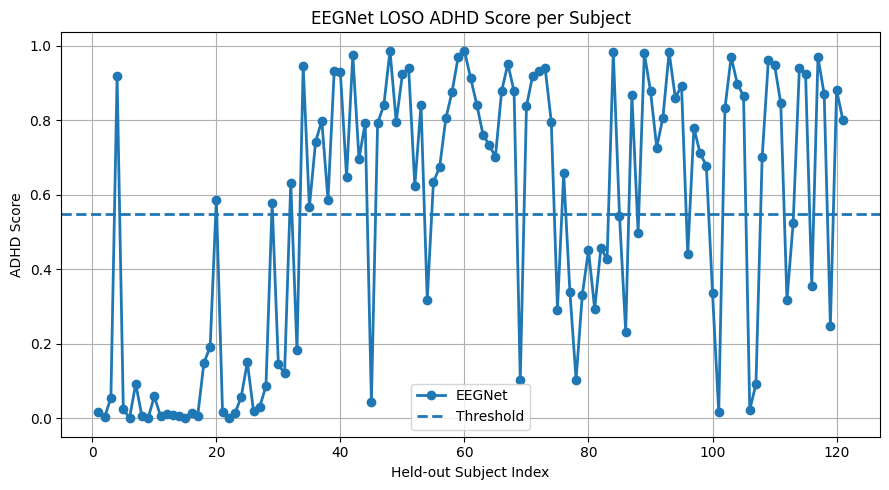

In [87]:
eegnet_plot = eegnet_loso_results_df.reset_index(drop=True).copy()
eegnet_plot["subject_index"] = range(1, len(eegnet_plot) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    eegnet_plot["subject_index"],
    eegnet_plot["subject_score"],
    marker="o",
    linewidth=2,
    label="EEGNet"
)

plt.axhline(
    y=THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Held-out Subject Index")
plt.ylabel("ADHD Score")
plt.title("EEGNet LOSO ADHD Score per Subject")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

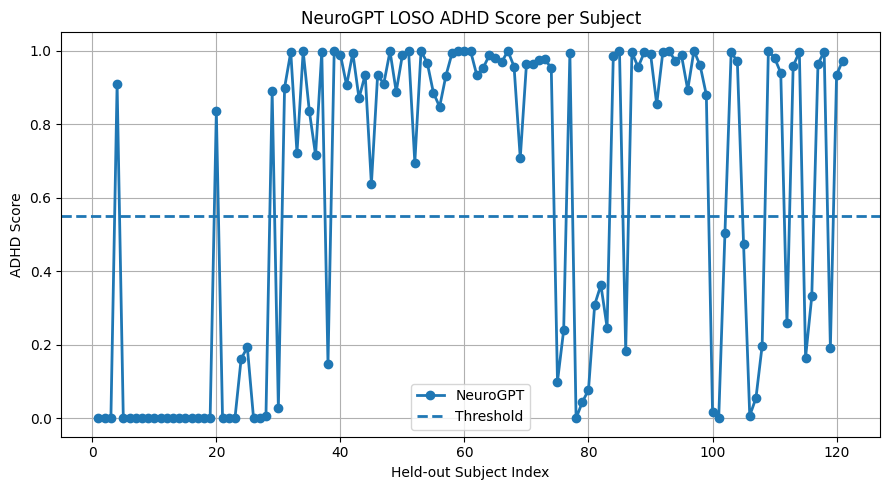

In [88]:
neurogpt_plot = neurogpt_loso_results_df.reset_index(drop=True).copy()
neurogpt_plot["subject_index"] = range(1, len(neurogpt_plot) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    neurogpt_plot["subject_index"],
    neurogpt_plot["subject_score"],
    marker="o",
    linewidth=2,
    label="NeuroGPT"
)

plt.axhline(
    y=THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Held-out Subject Index")
plt.ylabel("ADHD Score")
plt.title("NeuroGPT LOSO ADHD Score per Subject")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

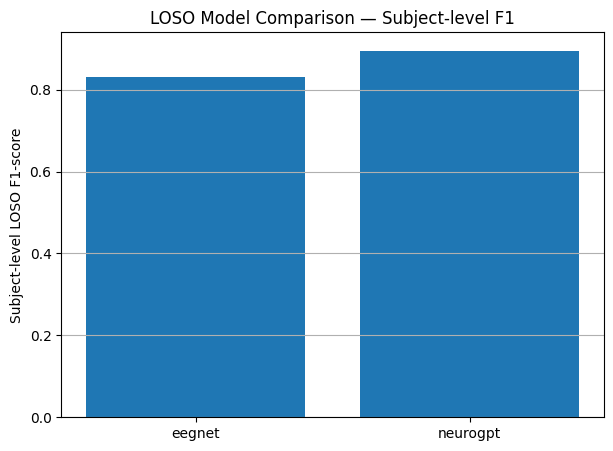

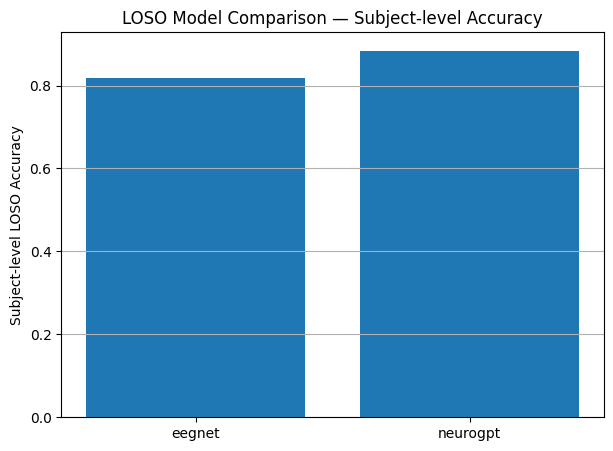

In [78]:
plot_df = loso_subject_summary_df.copy()

plt.figure(figsize=(7, 5))
plt.bar(plot_df["model"], plot_df["f1"])
plt.ylabel("Subject-level LOSO F1-score")
plt.title("LOSO Model Comparison — Subject-level F1")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(plot_df["model"], plot_df["accuracy"])
plt.ylabel("Subject-level LOSO Accuracy")
plt.title("LOSO Model Comparison — Subject-level Accuracy")
plt.grid(axis="y")
plt.show()


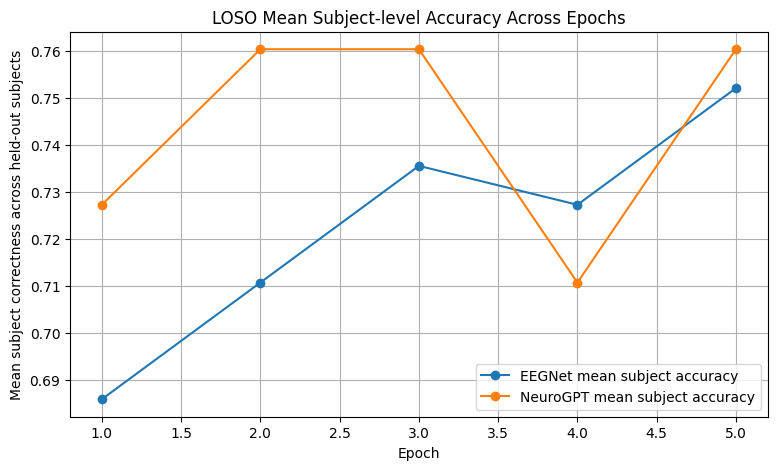

In [92]:
mean_curves = []

for model_name, histories in [
    ("EEGNet", eegnet_loso_histories),
    ("NeuroGPT", neurogpt_loso_histories),
]:
    tmp = pd.concat(histories.values(), ignore_index=True)
    curve = tmp.groupby("epoch")["correct"].agg(["mean", "std"]).reset_index()
    curve["model"] = model_name
    mean_curves.append(curve)

loso_mean_curves_df = pd.concat(mean_curves, ignore_index=True)
loso_mean_curves_df.to_csv("loso_mean_subject_accuracy_curves_eegnet_neurogpt.csv", index=False)

plt.figure(figsize=(9, 5))
for model_name in loso_mean_curves_df["model"].unique():
    sub = loso_mean_curves_df[loso_mean_curves_df["model"] == model_name]
    plt.plot(sub["epoch"], sub["mean"], marker="o", label=f"{model_name} mean subject accuracy")

plt.xlabel("Epoch")
plt.ylabel("Mean subject correctness across held-out subjects")
plt.title("LOSO Mean Subject-level Accuracy Across Epochs")
plt.legend()
plt.grid(True)
plt.show()


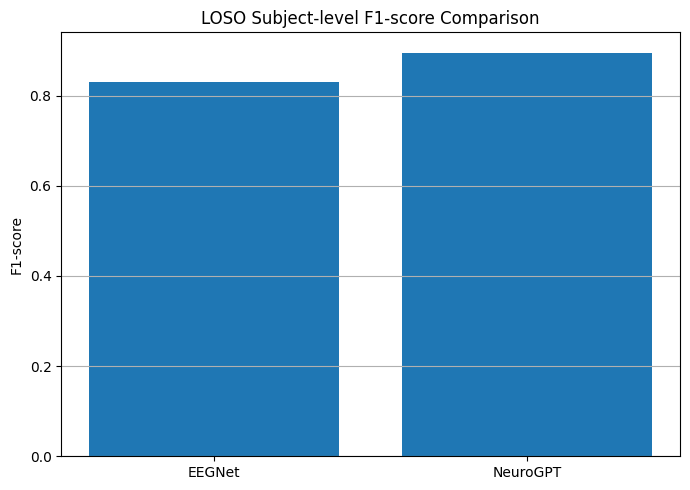

In [91]:
comparison_df = pd.DataFrame([
    {
        "model": "EEGNet",
        "f1": 0.830769
    },
    {
        "model": "NeuroGPT",
        "f1": 0.895522
    }
])

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["model"],
    comparison_df["f1"]
)

plt.ylabel("F1-score")
plt.title("LOSO Subject-level F1-score Comparison")
plt.grid(axis="y")
plt.tight_layout()
plt.show()